# Linear Algebra — A Worked, Executable Companion

This notebook is the "show your work" companion to the animated slide deck. Every
concept gets three things:

1. **The idea** — plain-language intuition
2. **The math** — the formal definition, and *why* it's defined that way (not just what it is)
3. **The code** — a NumPy example you can run, tweak, and break

Run the cells top to bottom — later sections reuse variables and helper functions
defined earlier (`plot_vectors`, etc.), exactly like a real analysis notebook.

**Contents:** Scalars → Vectors → Matrices → Tensors → Matrix Multiplication →
Identity → Inverse → Linear Systems → Rank → Null/Column Space → Determinant →
Trace → Eigenvalues/Eigenvectors → Diagonalization → Symmetric Matrices →
Orthogonality → Orthogonal Matrices → Gram-Schmidt → Basis → Independence & Span →
Vector Spaces → Change of Basis → Projection → Least Squares → SVD → Covariance →
PCA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

np.set_printoptions(precision=3, suppress=True)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

COLORS = {'a':'#3B7DD8','b':'#D8A63B','c':'#D8483B','d':'#3BA65C','e':'#8B6BD8','f':'#3BB6B0'}

def plot_vectors(vectors, colors=None, labels=None, xlim=(-1,5), ylim=(-1,5),
                  title="", origin_list=None, figsize=(4.6,4.6)):
    '''Draw 2D vectors as arrows from the origin (or a custom origin each).'''
    fig, ax = plt.subplots(figsize=figsize)
    colors = colors or list(COLORS.values())
    origin_list = origin_list or [(0,0)]*len(vectors)
    for i, v in enumerate(vectors):
        ox, oy = origin_list[i]
        ax.annotate('', xy=(ox+v[0], oy+v[1]), xytext=(ox, oy),
                    arrowprops=dict(arrowstyle='-|>', color=colors[i % len(colors)], lw=2.4,
                                    mutation_scale=18))
        if labels:
            lx, ly = ox+v[0], oy+v[1]
            ax.text(lx+0.12, ly+0.08, labels[i], color=colors[i % len(colors)],
                    fontsize=12, fontweight='bold')
    ax.axhline(0, color='#999', lw=0.8)
    ax.axvline(0, color='#999', lw=0.8)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_grid_transform(M, xlim=(-4,4), ylim=(-4,4), title=""):
    '''Show how a 2x2 matrix M warps a grid + the standard basis vectors.'''
    M = np.array(M, dtype=float)
    fig, axes = plt.subplots(1, 2, figsize=(9,4.4))
    lines_x = np.linspace(xlim[0], xlim[1], 9)
    lines_y = np.linspace(ylim[0], ylim[1], 9)

    for ax, mat, ttl in zip(axes, [np.eye(2), M], ["before  (identity)", title or "after  M @ grid"]):
        for x in lines_x:
            pts = np.array([[x, y] for y in np.linspace(ylim[0], ylim[1], 60)]).T
            tp = mat @ pts
            ax.plot(tp[0], tp[1], color='#999', lw=0.5)
        for y in lines_y:
            pts = np.array([[x, y] for x in np.linspace(xlim[0], xlim[1], 60)]).T
            tp = mat @ pts
            ax.plot(tp[0], tp[1], color='#999', lw=0.5)
        ihat = mat @ np.array([1,0]); jhat = mat @ np.array([0,1])
        ax.annotate('', xy=ihat, xytext=(0,0), arrowprops=dict(arrowstyle='-|>', color=COLORS['a'], lw=2.6))
        ax.annotate('', xy=jhat, xytext=(0,0), arrowprops=dict(arrowstyle='-|>', color=COLORS['b'], lw=2.6))
        ax.axhline(0, color='#666', lw=0.8); ax.axvline(0, color='#666', lw=0.8)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect('equal')
        ax.set_title(ttl, fontsize=11)
    plt.tight_layout()
    plt.show()

print("Setup complete: numpy", np.__version__, "| matplotlib", mpl.__version__)

Setup complete: numpy 2.4.4 | matplotlib 3.10.8


## 1. Scalars

**Idea.** A scalar is a single number — magnitude only, no direction. Every entry
inside a vector or matrix is, individually, a scalar.

**Math.** A scalar $c$ belongs to a *field* $\mathbb{F}$ (almost always $\mathbb{R}$
here). Scalars act on vectors through **scalar multiplication**:

$$(c \cdot v)_i = c \cdot v_i$$

**Why this definition?** We want scaling a vector to stretch/shrink/flip it without
changing its *direction line*. Multiplying every component by the same $c$ is the
only operation that does this consistently in every basis.

In [2]:
c = 5.0
v = np.array([2.0, 1.0])

print("scalar c =", c)
print("vector v =", v)
print("c * v    =", c * v, "  <- same direction, 5x longer")
print("-1 * v   =", -1 * v, " <- same line, opposite direction")

scalar c = 5.0
vector v = [2. 1.]
c * v    = [10.  5.]   <- same direction, 5x longer
-1 * v   = [-2. -1.]  <- same line, opposite direction


## 2. Vectors

**Idea.** A vector is an arrow: it has both length and direction. In code, it's
just an ordered tuple of numbers — but geometrically, that tuple *is* a point in
space reached by walking along each basis direction.

**Math.** $v \in \mathbb{R}^n$, written $v = (v_1, v_2, \ldots, v_n)$.

**Why this definition?** We need one object that captures "n independent pieces
of information that combine into a single point/direction." A tuple is the
simplest such object, and it matches the geometric picture: $v = v_1\hat{e}_1 + v_2\hat{e}_2 + \cdots$

v = [3. 2.]  -> read as: 3 steps along x, 2 steps along y


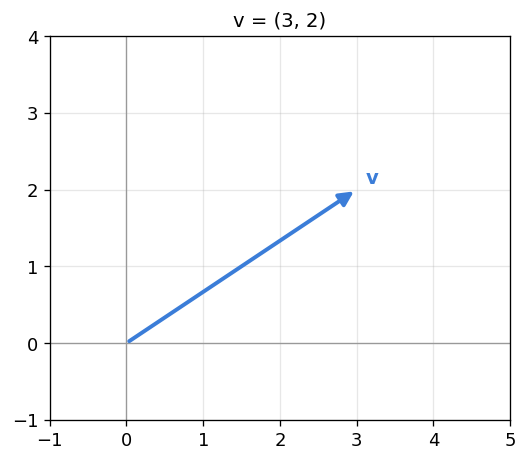

In [3]:
v = np.array([3.0, 2.0])
print("v =", v, " -> read as: 3 steps along x, 2 steps along y")

plot_vectors([v], colors=[COLORS['a']], labels=['v'], xlim=(-1,5), ylim=(-1,4),
             title="v = (3, 2)")

## 3. Vector Operations: Addition & Scalar Multiplication

**Math.**
$$(a+b)_i = a_i + b_i \qquad (c \cdot a)_i = c \cdot a_i$$

**Why this definition?** We want vector addition to mirror physically combining
two displacements: walk along $a$, then walk along $b$ — the total displacement's
$x$-component is just the sum of the two $x$-steps, and same for $y$. That is
*exactly* component-wise addition. Geometrically this is the "tip-to-tail" rule.

a       = [2. 1.]
b       = [1. 2.]
a + b   = [3. 3.]
2 * a   = [4. 2.]
-1 * a  = [-2. -1.]


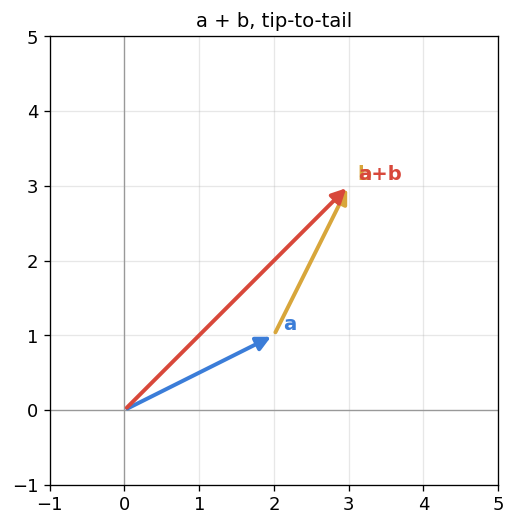

In [4]:
a = np.array([2.0, 1.0])
b = np.array([1.0, 2.0])
s = a + b
print("a       =", a)
print("b       =", b)
print("a + b   =", s)
print("2 * a   =", 2*a)
print("-1 * a  =", -1*a)

# tip-to-tail: draw b starting where a ends
plot_vectors([a, b, s], colors=[COLORS['a'], COLORS['b'], COLORS['c']],
             labels=['a','b','a+b'], origin_list=[(0,0), (a[0],a[1]), (0,0)],
             xlim=(-1,5), ylim=(-1,5), title="a + b, tip-to-tail")

## 4. Norm & Length

**Math.** $\displaystyle \|v\| = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}$

**Why this definition?** Along perpendicular (orthogonal) axes, the straight-line
distance from the origin decomposes into right-angle legs — that's the
Pythagorean theorem, $a^2+b^2=c^2$. The norm is just this theorem generalized to
$n$ dimensions. It's the unique definition of "length" consistent with a
right-angle coordinate grid.

In [5]:
v = np.array([4.0, 3.0])
norm_manual = np.sqrt(np.sum(v**2))
norm_numpy = np.linalg.norm(v)
unit = v / norm_numpy

print("v            =", v)
print("||v|| (manual) =", norm_manual)
print("||v|| (numpy)  =", norm_numpy)
print("unit vector  =", unit, "  (||unit|| =", np.linalg.norm(unit), ")")

v            = [4. 3.]
||v|| (manual) = 5.0
||v|| (numpy)  = 5.0
unit vector  = [0.8 0.6]   (||unit|| = 1.0 )


## 5. Matrices

**Idea.** A matrix is a rectangular grid of numbers. Geometrically, it's a
*machine*: feed it a vector, it hands back a transformed vector. Each **column**
tells you where one basis vector ends up.

**Math.** $A \in \mathbb{R}^{m \times n}$ has entries $a_{ij}$ (row $i$, column $j$),
and represents a linear map $\mathbb{R}^n \to \mathbb{R}^m$.

**Why this shape?** To describe where *every* one of the $n$ input basis
directions lands, you need $n$ output vectors — each living in the $m$-dimensional
output space. Stacking those $n$ vectors as columns gives exactly an $m \times n$
grid, and that grid is precisely what matrix-vector multiplication needs.

In [6]:
A = np.array([
    [2, 0, 1],
    [1, 3, 2],
    [0, 1, 2]
])
print("A =\n", A)
print("shape:", A.shape, " (rows, cols)")
print("column 1 (index 0):", A[:, 0], " <- where e1 lands")
print("column 2 (index 1):", A[:, 1], " <- where e2 lands")
print("entry a[1,2] =", A[1, 2], " (row 1, col 2)")

A =
 [[2 0 1]
 [1 3 2]
 [0 1 2]]
shape: (3, 3)  (rows, cols)
column 1 (index 0): [2 1 0]  <- where e1 lands
column 2 (index 1): [0 3 1]  <- where e2 lands
entry a[1,2] = 2  (row 1, col 2)


## 6. Transpose

**Math.** $(A^T)_{ij} = A_{ji}$. Key identities:
$$(A^T)^T = A \qquad (A+B)^T = A^T+B^T \qquad (AB)^T = B^T A^T$$

**Why does $(AB)^T$ reverse the order?** Transposing swaps every index pair. If
you write out $(AB)_{ij} = \sum_k A_{ik}B_{kj}$ and swap $i \leftrightarrow j$
everywhere, you get $\sum_k A_{jk}B_{ki} = \sum_k B_{ki}A_{jk} = (B^T A^T)_{ij}$ —
the order *must* flip to keep the sum's indices matching.

In [7]:
A = np.array([[2,5,1],[3,0,4]])
print("A  shape", A.shape, "=\n", A)
print("\nA.T shape", A.T.shape, "=\n", A.T)
print("\n(A.T).T == A ?", np.array_equal(A.T.T, A))

B = np.random.default_rng(0).integers(0,5,size=(3,2))
lhs = (A @ B).T
rhs = B.T @ A.T
print("\n(AB).T == B.T @ A.T ?", np.allclose(lhs, rhs))

A  shape (2, 3) =
 [[2 5 1]
 [3 0 4]]

A.T shape (3, 2) =
 [[2 3]
 [5 0]
 [1 4]]

(A.T).T == A ? True

(AB).T == B.T @ A.T ? True


## 7. Tensors

**Idea.** Scalars, vectors, and matrices are the first three members of one
family, distinguished only by how many indices you need to address an entry.

| Object | Indices needed | "Rank"/"Order" |
|---|---|---|
| Scalar | none | 0 |
| Vector | 1 (which entry) | 1 |
| Matrix | 2 (row, col) | 2 |
| Tensor | $N$ | $N$ |

**Why generalize this way?** Real data often needs more than 2 indices — a
batch of color video frames needs (batch, time, height, width, channel), five
indices. Rather than invent new algebra, we keep the same index-based rules
(addition, scaling, contraction) and simply allow more of them.

In [8]:
scalar = np.array(7.0)
vector = np.array([1.0, 2.0, 3.0])
matrix = np.array([[1.0,2.0],[3.0,4.0]])
tensor3 = np.random.default_rng(1).normal(size=(2,3,4))

for name, obj in [('scalar', scalar), ('vector', vector), ('matrix', matrix), ('rank-3 tensor', tensor3)]:
    print(f"{name:14s}  ndim={obj.ndim}  shape={obj.shape}")

scalar          ndim=0  shape=()
vector          ndim=1  shape=(3,)
matrix          ndim=2  shape=(2, 2)
rank-3 tensor   ndim=3  shape=(2, 3, 4)


## 8. Matrix Multiplication

**Math.** $(Mv)_i = \sum_j M_{ij} v_j$, and for two matrices,
$(AB)_{ij} = \sum_k A_{ik}B_{kj}$.

**Why this rule (and not, say, entrywise multiplication)?** We want $AB$ to mean
"first apply $B$, then apply $A$" as a *single* matrix — i.e. $(AB)v = A(Bv)$ for
every $v$. Expanding both sides with the definition of matrix-vector product is
the only combination rule that makes this composition identity hold in general.
Consequently $AB \neq BA$ in general — order matters, because "rotate then
stretch" differs from "stretch then rotate."

M =
 [[2 1]
 [1 2]]
v = [2 1]
Mv (by hand, row.column) = [5 4]
Mv (numpy @)             = [5 4]

(AB)v == A(Bv) ? True
AB == BA ?         False  <- order matters!


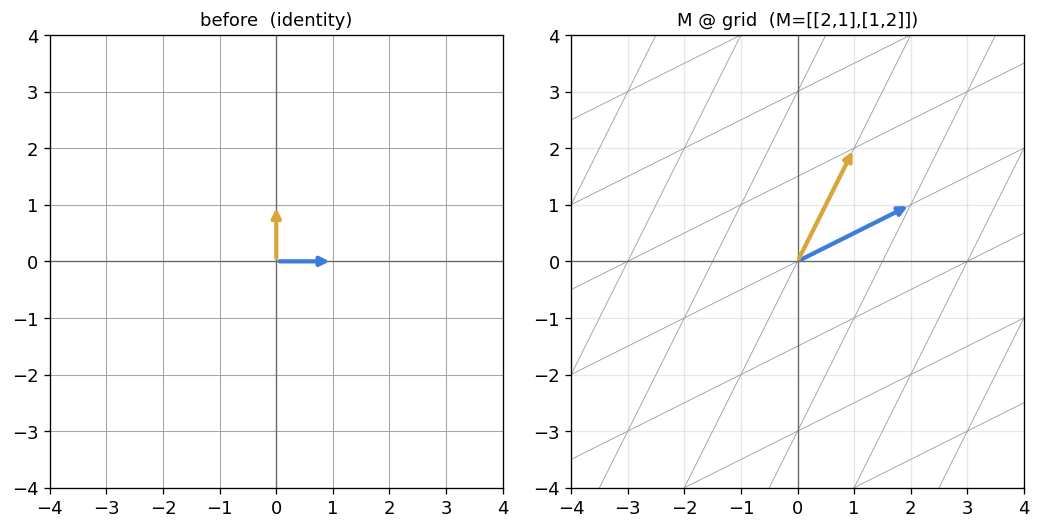

In [9]:
M = np.array([[2,1],[1,2]])
v = np.array([2,1])

Mv_formula = np.array([sum(M[i,j]*v[j] for j in range(2)) for i in range(2)])
Mv_numpy = M @ v
print("M =\n", M)
print("v =", v)
print("Mv (by hand, row.column) =", Mv_formula)
print("Mv (numpy @)             =", Mv_numpy)

# composition property: (AB)v == A(Bv)
A = np.array([[0,-1],[1,0]])   # 90 degree rotation
B = np.array([[2,0],[0,0.5]])  # stretch
lhs = (A @ B) @ v
rhs = A @ (B @ v)
print("\n(AB)v == A(Bv) ?", np.allclose(lhs, rhs))
print("AB == BA ?        ", np.allclose(A@B, B@A), " <- order matters!")

plot_grid_transform(M, title="M @ grid  (M=[[2,1],[1,2]])")

## 9. Identity Matrix

**Math.** $I_{ij} = \delta_{ij}$ (1 if $i=j$, else 0). $\quad AI = IA = A$.

**Why this shape?** We need a "do nothing" transformation so matrix
multiplication has a neutral element (like $1$ for scalar multiplication). Since
a matrix's columns show where basis vectors land, "do nothing" means column $j$
must be exactly $\hat e_j$ — which is precisely the diagonal-of-ones matrix.

I =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

I @ A == A ? True
A @ I == A ? True


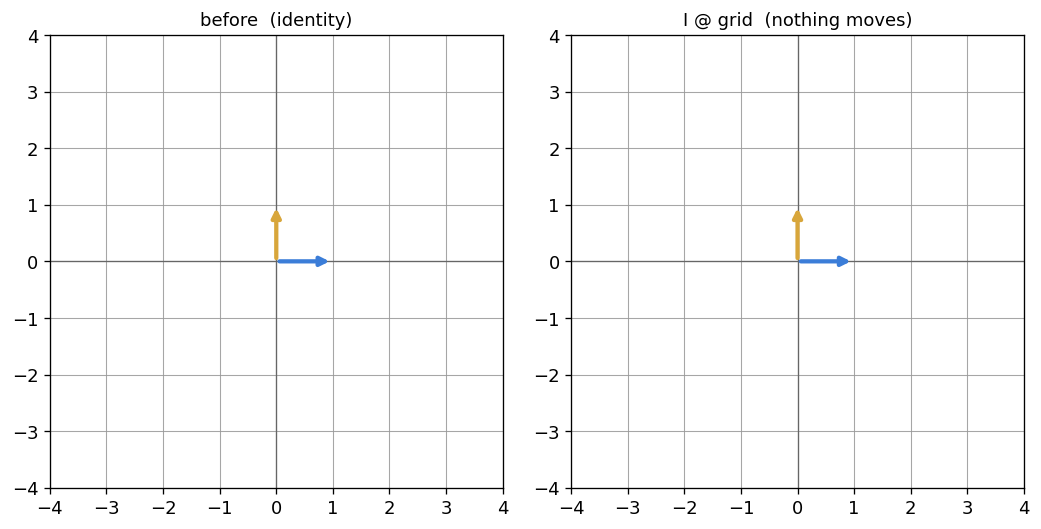

In [10]:
I = np.eye(3)
A = np.array([[2,0,1],[1,3,2],[0,1,2]])
print("I =\n", I)
print("\nI @ A == A ?", np.allclose(I @ A, A))
print("A @ I == A ?", np.allclose(A @ I, A))

plot_grid_transform(np.eye(2), title="I @ grid  (nothing moves)")

## 10. Inverse

**Math.** $A^{-1}$ satisfies $AA^{-1}=A^{-1}A=I$. For a $2\times2$ matrix
$\begin{bmatrix}a&b\\c&d\end{bmatrix}$:
$$A^{-1} = \frac{1}{ad-bc}\begin{bmatrix}d&-b\\-c&a\end{bmatrix}$$

**Why this formula, and why does it sometimes not exist?** We're solving
$AA^{-1}=I$ algebraically for the unknown entries of $A^{-1}$ — carrying out
that algebra for a general $2\times2$ matrix produces exactly the swap-and-negate
formula above, divided by $ad-bc$ (the determinant). If $ad-bc=0$, the formula
divides by zero — geometrically, $A$ has collapsed the plane into a line, so
multiple inputs share one output, and there's no way to reverse that.

In [11]:
M = np.array([[2.0,1.0],[1.0,1.5]])
Minv = np.linalg.inv(M)
print("M =\n", M)
print("\nM^-1 =\n", Minv)
print("\nM @ M^-1 == I ?", np.allclose(M @ Minv, np.eye(2)))

# the 2x2 shortcut formula, done by hand
a,b,c,d = M[0,0],M[0,1],M[1,0],M[1,1]
det = a*d - b*c
Minv_formula = (1/det) * np.array([[d,-b],[-c,a]])
print("\nby-hand formula matches np.linalg.inv:", np.allclose(Minv_formula, Minv))

# a singular (non-invertible) matrix
singular = np.array([[2.0,4.0],[1.0,2.0]])
print("\nsingular matrix det =", np.linalg.det(singular), " -> no inverse exists")
try:
    np.linalg.inv(singular)
except np.linalg.LinAlgError as e:
    print("numpy confirms:", e)

M =
 [[2.  1. ]
 [1.  1.5]]

M^-1 =
 [[ 0.75 -0.5 ]
 [-0.5   1.  ]]

M @ M^-1 == I ? True

by-hand formula matches np.linalg.inv: True

singular matrix det = 0.0  -> no inverse exists
numpy confirms: Singular matrix


## 11. Linear Systems ($Ax = b$)

**Math.** A system like $2x_1+x_2=4,\ x_1+x_2=3$ is exactly the matrix equation
$Ax=b$ with $A=\begin{bmatrix}2&1\\1&1\end{bmatrix}$, $b=\begin{bmatrix}4\\3\end{bmatrix}$.

**Why does solving it mean computing $A^{-1}b$?** $Ax=b$ asks "which input $x$
does $A$ send to the known output $b$?" — literally the inverse question to
matrix multiplication. If $A$ is invertible, left-multiplying both sides by
$A^{-1}$ isolates $x = A^{-1}b$ directly.

In [12]:
A = np.array([[2.0,1.0],[1.0,1.0]])
b = np.array([4.0,3.0])

x_inverse = np.linalg.inv(A) @ b
x_solve = np.linalg.solve(A, b)   # preferred: more numerically stable
print("A =\n", A, "\nb =", b)
print("\nx (via A^-1 @ b) =", x_inverse)
print("x (via np.linalg.solve) =", x_solve)
print("\ncheck: A @ x == b ?", np.allclose(A @ x_solve, b))

A =
 [[2. 1.]
 [1. 1.]] 
b = [4. 3.]

x (via A^-1 @ b) = [1. 2.]
x (via np.linalg.solve) = [1. 2.]

check: A @ x == b ? True


## 12. Rank

**Math.** $\text{rank}(A) = \dim(\text{column space of } A)$ — the number of
truly independent output directions $A$ can reach.

**Why defined this way?** The column space is *literally* the set of all
possible outputs $\{Av : v \in \mathbb{R}^n\}$. If some columns are linear
combinations of others, they add no new reachable directions — so counting
independent columns tells you exactly how many output dimensions survive.

full_rank =
 [[2.  0.4]
 [0.3 1.3]]
rank: 2  -> fills the whole plane

rank_deficient =
 [[2. 4.]
 [1. 2.]]
rank: 1  -> collapses to a line


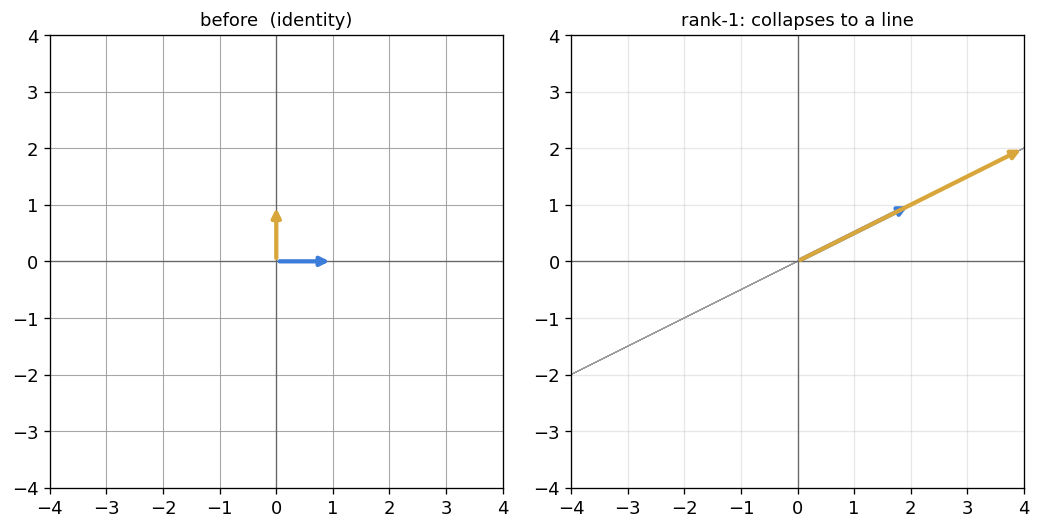

In [13]:
full_rank = np.array([[2.0,0.4],[0.3,1.3]])
rank_deficient = np.array([[2.0,4.0],[1.0,2.0]])   # col2 = 2 * col1

print("full_rank =\n", full_rank)
print("rank:", np.linalg.matrix_rank(full_rank), " -> fills the whole plane")

print("\nrank_deficient =\n", rank_deficient)
print("rank:", np.linalg.matrix_rank(rank_deficient), " -> collapses to a line")

plot_grid_transform(rank_deficient, title="rank-1: collapses to a line")

## 13. Null Space & Column Space

**Math.**
$$\text{null}(A) = \{x : Ax = 0\} \qquad \text{col}(A) = \{Ax : x \in \mathbb{R}^n\}$$
$$\dim(\text{null}(A)) + \text{rank}(A) = n \quad \text{(rank-nullity theorem)}$$

**Why?** Every input dimension either gets "absorbed" into the null space
(mapped to zero, contributing nothing to the output) or survives to create a
new output direction (contributing to the column space). Since there are only
$n$ input dimensions total, these two counts must add up to $n$.

In [14]:
from scipy.linalg import null_space

A = np.array([[2.0,4.0],[1.0,2.0]])
ns = null_space(A)
print("A =\n", A)
print("\nnull space basis vector(s):\n", ns)
print("check A @ (null vector) ==~ 0 ?", np.allclose(A @ ns, 0))

rank = np.linalg.matrix_rank(A)
nullity = ns.shape[1]
print(f"\nrank = {rank}, nullity = {nullity}, rank + nullity = {rank+nullity} = n (2 columns)")

A =
 [[2. 4.]
 [1. 2.]]

null space basis vector(s):
 [[ 0.894]
 [-0.447]]
check A @ (null vector) ==~ 0 ? True

rank = 1, nullity = 1, rank + nullity = 2 = n (2 columns)


## 14. Determinant

**Math.** For $2\times2$: $\det\begin{bmatrix}a&b\\c&d\end{bmatrix} = ad-bc$.

**Why this formula?** $ad-bc$ is exactly the signed area of the parallelogram
spanned by the column vectors $(a,c)$ and $(b,d)$ — you can derive it directly
from the shoelace/cross-product area formula. That makes $|\det A|$ the natural
"area scale factor" of the transformation, and the *sign* tells you whether
orientation flips (a mirror-like transformation).

M =
 [[2.  0.6]
 [0.2 1.3]]
det(M) [numpy] = 2.48
det(M) [ad-bc] = 2.48
-> a unit square becomes a parallelogram of area 2.48

det(flip) = -1.0  <- negative: orientation reversed (mirrored)


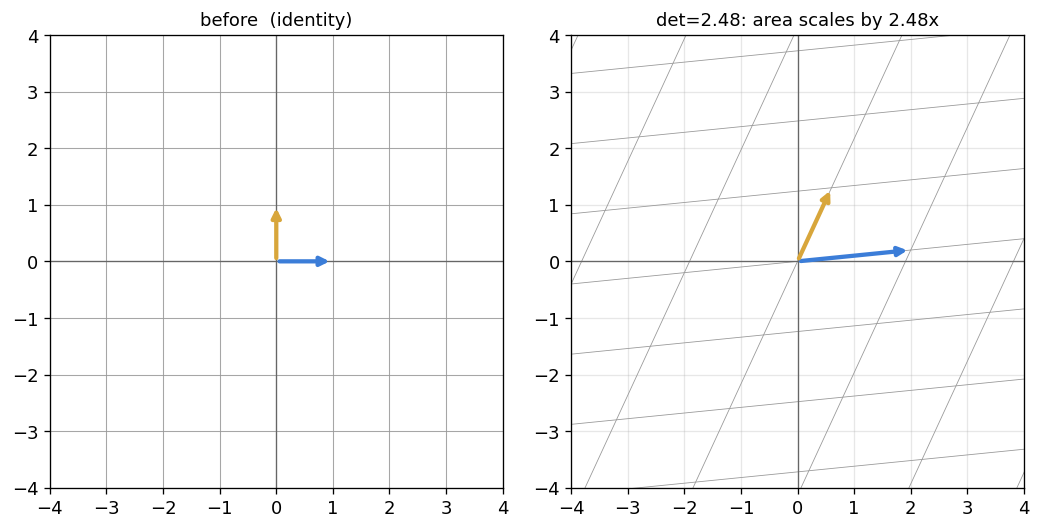

In [15]:
M = np.array([[2.0,0.6],[0.2,1.3]])
det = np.linalg.det(M)
manual_det = M[0,0]*M[1,1] - M[0,1]*M[1,0]
print("M =\n", M)
print("det(M) [numpy] =", det)
print("det(M) [ad-bc] =", manual_det)
print("-> a unit square becomes a parallelogram of area", abs(det))

flip = np.array([[-1.0,0.0],[0.0,1.0]])
print("\ndet(flip) =", np.linalg.det(flip), " <- negative: orientation reversed (mirrored)")

plot_grid_transform(M, title=f"det={det:.2f}: area scales by {abs(det):.2f}x")

## 15. Trace

**Math.** $\text{tr}(A) = \sum_i a_{ii}$ (sum of diagonal entries).
Also: $\text{tr}(A) = \sum_i \lambda_i$ (sum of eigenvalues), and
$\text{tr}(AB)=\text{tr}(BA)$.

**Why does trace equal the sum of eigenvalues?** The characteristic polynomial
$\det(A-\lambda I)$ expands to $(-1)^n\lambda^n + (-1)^{n-1}\text{tr}(A)\lambda^{n-1}+\cdots$.
Comparing this to the polynomial's factored form $\prod_i(\lambda_i - \lambda)$
and matching the $\lambda^{n-1}$ coefficient shows the eigenvalues must sum to
$\text{tr}(A)$ — a nice, basis-independent "summary number."

In [16]:
A = np.array([[4.0,1.0,0.0],[2.0,3.0,1.0],[0.0,2.0,5.0]])
tr = np.trace(A)
eigvals = np.linalg.eigvals(A)
print("A =\n", A)
print("\ntrace(A) [diagonal sum] =", tr)
print("sum of eigenvalues      =", eigvals.sum().real)
print("eigenvalues:", eigvals)

B = np.random.default_rng(2).normal(size=(3,3))
print("\ntr(AB) == tr(BA) ?", np.isclose(np.trace(A@B), np.trace(B@A)))

A =
 [[4. 1. 0.]
 [2. 3. 1.]
 [0. 2. 5.]]

trace(A) [diagonal sum] = 12.0
sum of eigenvalues      = 11.999999999999998
eigenvalues: [1.586 4.414 6.   ]

tr(AB) == tr(BA) ? True


## 16. Eigenvalues & Eigenvectors

**Math.** $Av = \lambda v$ for some nonzero $v$. Rearranged: $(A-\lambda I)v=0$,
which has a nonzero solution only when $A-\lambda I$ is singular:
$$\det(A - \lambda I) = 0 \quad \text{(the characteristic equation)}$$

**Why look for $Av=\lambda v$ in the first place?** We want the "natural axes"
of a transformation — directions that don't get rotated or mixed with others,
only stretched. $(A-\lambda I)v=0$ has a nonzero solution exactly when
$A-\lambda I$ collapses space (is singular), which is precisely when its
determinant is zero — giving a polynomial we can solve for $\lambda$.

characteristic eq: lambda^2 - 6.0*lambda + 8.000000000000002 = 0
solved by hand -> lambda = 3.999999999999999 and 2.000000000000001

numpy eigenvalues : [4. 2.]
numpy eigenvectors (columns):
 [[ 0.707 -0.707]
 [ 0.707  0.707]]

check Av == lambda*v: True


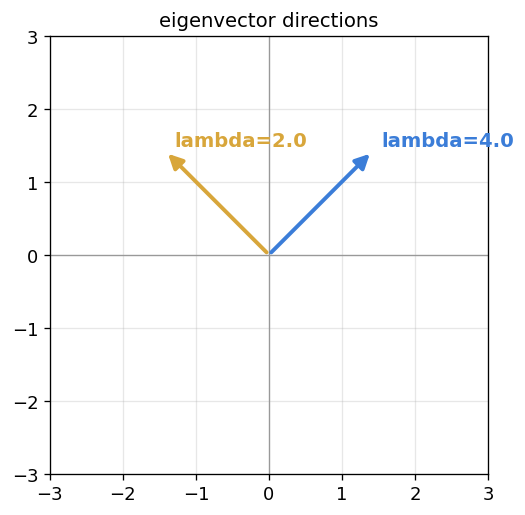

In [17]:
A = np.array([[3.0,1.0],[1.0,3.0]])

# solve by hand: characteristic polynomial
tr, det = np.trace(A), np.linalg.det(A)
# lambda^2 - tr*lambda + det = 0
disc = np.sqrt(tr**2 - 4*det)
lam1, lam2 = (tr+disc)/2, (tr-disc)/2
print(f"characteristic eq: lambda^2 - {tr}*lambda + {det} = 0")
print("solved by hand -> lambda =", lam1, "and", lam2)

eigvals, eigvecs = np.linalg.eig(A)
print("\nnumpy eigenvalues :", eigvals)
print("numpy eigenvectors (columns):\n", eigvecs)

# verify Av = lambda v for the first eigenpair
v0 = eigvecs[:,0]; l0 = eigvals[0]
print("\ncheck Av == lambda*v:", np.allclose(A @ v0, l0 * v0))

plot_vectors([eigvecs[:,0]*2, eigvecs[:,1]*2], colors=[COLORS['a'],COLORS['b']],
             labels=[f'lambda={eigvals[0]:.1f}', f'lambda={eigvals[1]:.1f}'],
             xlim=(-3,3), ylim=(-3,3), title="eigenvector directions")

## 17. Diagonalization

**Math.** If $A$ has $n$ independent eigenvectors, $A = QDQ^{-1}$, where $Q$'s
columns are the eigenvectors and $D$ is diagonal with the eigenvalues.

**Why?** In the coordinate system defined by its own eigenvectors, a
transformation has nothing left to do but scale each axis independently — no
mixing between directions. $Q$ converts *into* that eigenbasis, $D$ does the
simple per-axis scaling, and $Q^{-1}$ converts back — composed, that's exactly
what $A$ does in the standard basis.

In [18]:
A = np.array([[3.0,1.0],[1.0,3.0]])
eigvals, Q = np.linalg.eig(A)
D = np.diag(eigvals)
Qinv = np.linalg.inv(Q)

reconstructed = Q @ D @ Qinv
print("Q (eigenvectors) =\n", Q)
print("\nD (eigenvalues on diagonal) =\n", D)
print("\nQ @ D @ Q^-1 =\n", reconstructed)
print("\nmatches A ?", np.allclose(reconstructed, A))

# the payoff: A^10 becomes trivial via diagonalization
A10_direct = np.linalg.matrix_power(A, 10)
A10_diag = Q @ np.diag(eigvals**10) @ Qinv
print("\nA^10 direct == Q @ D^10 @ Q^-1 ?", np.allclose(A10_direct, A10_diag))

Q (eigenvectors) =
 [[ 0.707 -0.707]
 [ 0.707  0.707]]

D (eigenvalues on diagonal) =
 [[4. 0.]
 [0. 2.]]

Q @ D @ Q^-1 =
 [[3. 1.]
 [1. 3.]]

matches A ? True

A^10 direct == Q @ D^10 @ Q^-1 ? True


## 18. Symmetric Matrices & the Spectral Theorem

**Math.** $A=A^T$. The **spectral theorem** guarantees: real eigenvalues, and
eigenvectors that are automatically orthogonal, so $A=Q\Lambda Q^T$ with $Q$
orthogonal ($Q^TQ=I$).

**Why does symmetry force this nice structure?** For real eigenvalues: if $v$
is a (possibly complex) eigenvector, $v^H A v$ is provably real when $A=A^T$,
which forces $\lambda$ real. For orthogonality: take two eigenvectors $v_1,v_2$
with $\lambda_1 \ne \lambda_2$; then
$\lambda_1 (v_1\!\cdot\!v_2) = (Av_1)\!\cdot\!v_2 = v_1\!\cdot\!(Av_2) = \lambda_2(v_1\!\cdot\!v_2)$
(using $A=A^T$) forces $v_1\!\cdot\!v_2=0$ whenever $\lambda_1\ne\lambda_2$.

In [19]:
A = np.array([[3.0,1.0],[1.0,3.0]])
print("A == A.T ?", np.array_equal(A, A.T))

eigvals, eigvecs = np.linalg.eigh(A)   # eigh = symmetric-aware, guarantees orthonormal output
print("\neigenvalues (real):", eigvals)
v1, v2 = eigvecs[:,0], eigvecs[:,1]
print("v1 . v2 =", np.dot(v1, v2), " <- orthogonal (~0)")
print("||v1|| =", np.linalg.norm(v1), " ||v2|| =", np.linalg.norm(v2), " <- unit length")

Q = eigvecs
reconstructed = Q @ np.diag(eigvals) @ Q.T
print("\nA == Q @ Lambda @ Q.T ?", np.allclose(reconstructed, A))

A == A.T ? True

eigenvalues (real): [2. 4.]
v1 . v2 = 2.2371143170757382e-17  <- orthogonal (~0)
||v1|| = 0.9999999999999999  ||v2|| = 0.9999999999999999  <- unit length

A == Q @ Lambda @ Q.T ? True


## 19. Orthogonality

**Math.** $a\cdot b = \sum_i a_ib_i = \|a\|\|b\|\cos\theta$. Perpendicular
($\theta=90°$) $\iff a\cdot b = 0$.

**Why does the componentwise sum equal $\|a\|\|b\|\cos\theta$?** Expand
$\|a-b\|^2 = \|a\|^2+\|b\|^2-2(a\cdot b)$ using the componentwise definition,
and compare with the Law of Cosines, $c^2=a^2+b^2-2ab\cos\theta$, applied to the
triangle formed by $a$, $b$, and $a-b$. Both describe the same triangle, so the
two expressions for the cross term must be equal — that's the identity.

a . b = 0.0  -> perpendicular
cos(theta) = 0.0  -> theta = 90.0 degrees

a . c = 6.0  -> not zero, not perpendicular


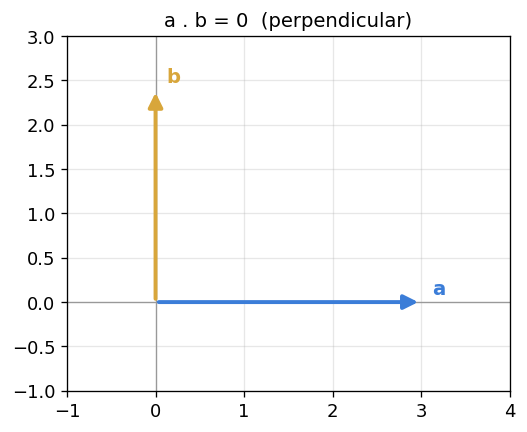

In [20]:
a = np.array([3.0, 0.0])
b = np.array([0.0, 2.4])
dot = np.dot(a, b)
print("a . b =", dot, " -> perpendicular")

cos_theta = np.dot(a,b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12)
print("cos(theta) =", cos_theta, " -> theta =", np.degrees(np.arccos(np.clip(cos_theta,-1,1))), "degrees")

c = np.array([2.0, 1.5])   # not perpendicular to a
print("\na . c =", np.dot(a, c), " -> not zero, not perpendicular")

plot_vectors([a,b], colors=[COLORS['a'],COLORS['b']], labels=['a','b'],
             xlim=(-1,4), ylim=(-1,3), title="a . b = 0  (perpendicular)")

## 20. Orthogonal Matrices

**Math.** $Q^TQ = QQ^T = I$, equivalently $Q^{-1}=Q^T$ (cheap to invert!).

**Why does $Q^TQ=I$ mean "rotation/reflection only, no stretching"?** $(Q^TQ)_{ij}$
is the dot product of columns $i$ and $j$ of $Q$. Requiring this to equal $I$
means every column has unit length (diagonal = 1) *and* every pair of columns is
perpendicular (off-diagonal = 0) — exactly the conditions needed to preserve
every vector's length and every angle between vectors after transforming.

Q (rotation by 35 deg) =
 [[ 0.819 -0.574]
 [ 0.574  0.819]]

Q.T @ Q =
 [[ 1. -0.]
 [-0.  1.]]  <- identity
Q.T == Q^-1 ? True

||v|| = 2.23606797749979    ||Qv|| = 2.23606797749979  <- length preserved


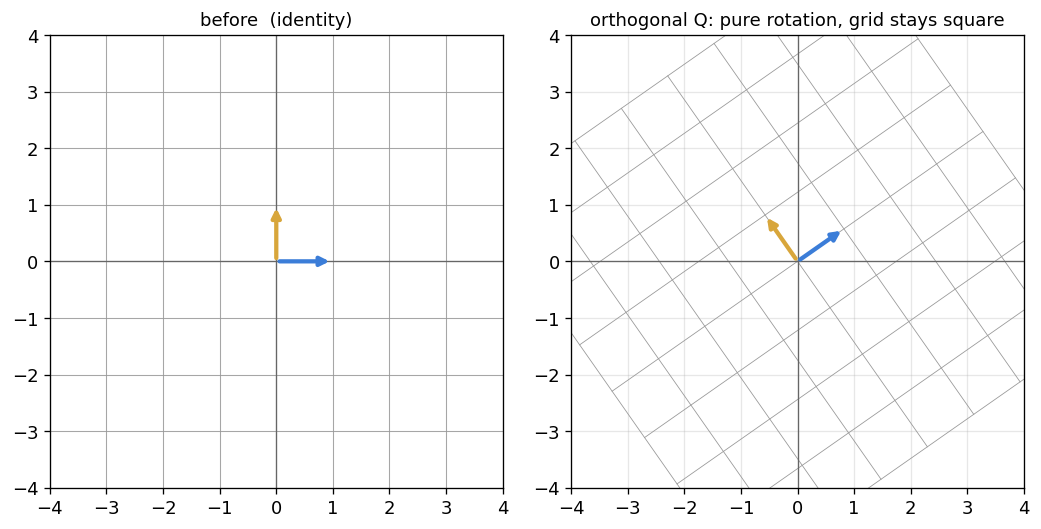

In [21]:
theta = np.radians(35)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print("Q (rotation by 35 deg) =\n", Q)
print("\nQ.T @ Q =\n", Q.T @ Q, " <- identity")
print("Q.T == Q^-1 ?", np.allclose(Q.T, np.linalg.inv(Q)))

v = np.array([2.0, 1.0])
print("\n||v|| =", np.linalg.norm(v), "   ||Qv|| =", np.linalg.norm(Q @ v), " <- length preserved")

plot_grid_transform(Q, title="orthogonal Q: pure rotation, grid stays square")

## 21. Gram-Schmidt Process

**Math.** Given independent $a, b$: keep $u_1=a$; then
$$u_2 = b - \frac{a\cdot b}{a\cdot a}\,a$$

**Why does subtracting the projection leave something perpendicular?** The
projection $\frac{a\cdot b}{a\cdot a}a$ is *defined* as the part of $b$ pointing
along $a$. Whatever remains, $u_2 = b - \text{proj}$, is by construction the
"leftover" — and you can verify $u_2 \cdot a = 0$ directly by substitution.
Repeating this against every previous direction builds a full orthogonal set.

u1 = a          = [3.  0.6]
projection of b onto a = [1.846 0.369]
u2 = b - proj   = [-0.446  2.231]

u1 . u2 = 7.498275504776057e-16  <- orthogonal (~0)

orthonormal basis:
e1 = [0.981 0.196]   e2 = [-0.196  0.981]
e1 . e2 = 7.009403759608102e-17


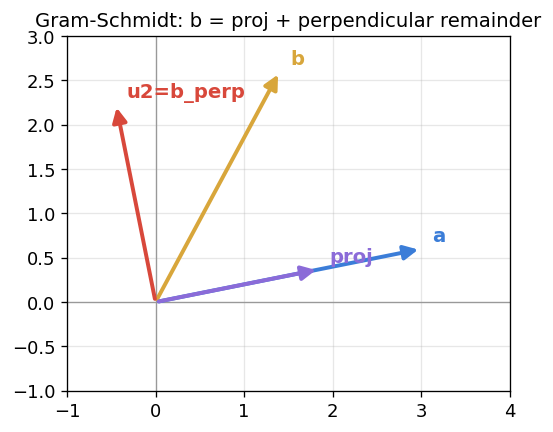

In [22]:
a = np.array([3.0, 0.6])
b = np.array([1.4, 2.6])

u1 = a
proj = (np.dot(a,b)/np.dot(a,a)) * a
u2 = b - proj

print("u1 = a          =", u1)
print("projection of b onto a =", proj)
print("u2 = b - proj   =", u2)
print("\nu1 . u2 =", np.dot(u1,u2), " <- orthogonal (~0)")

e1, e2 = u1/np.linalg.norm(u1), u2/np.linalg.norm(u2)
print("\northonormal basis:")
print("e1 =", e1, "  e2 =", e2)
print("e1 . e2 =", np.dot(e1,e2))

plot_vectors([a,b,proj,u2], colors=[COLORS['a'],COLORS['b'],COLORS['e'],COLORS['c']],
             labels=['a','b','proj','u2=b_perp'], xlim=(-1,4), ylim=(-1,3),
             title="Gram-Schmidt: b = proj + perpendicular remainder")

## 22. Basis

**Math.** A basis is a set $\{e_1,\ldots,e_n\}$ that is (1) independent and
(2) spans the whole space. Every vector then has a **unique** representation
$v = c_1e_1+\cdots+c_ne_n$.

**Why "minimal and complete"?** Fewer vectors couldn't reach every point
(not spanning); more vectors would make the coordinates non-unique (redundant —
some vector could be written two different ways). The basis is the exact
"just enough" set.

In [23]:
e1 = np.array([1.0,0.0])
e2 = np.array([0.0,1.0])
v = 3*e1 + 2*e2
print("standard basis: e1 =", e1, " e2 =", e2)
print("v = 3*e1 + 2*e2 =", v)

# a DIFFERENT (non-standard) basis
f1 = np.array([1.0,1.0])
f2 = np.array([1.0,-1.0])
B = np.column_stack([f1,f2])
coords_in_B = np.linalg.solve(B, v)
print("\nnon-standard basis f1 =", f1, " f2 =", f2)
print("v in terms of f1,f2:  coords =", coords_in_B)
print("check:", coords_in_B[0], "* f1 +", coords_in_B[1], "* f2 =", coords_in_B[0]*f1 + coords_in_B[1]*f2)

standard basis: e1 = [1. 0.]  e2 = [0. 1.]
v = 3*e1 + 2*e2 = [3. 2.]

non-standard basis f1 = [1. 1.]  f2 = [ 1. -1.]
v in terms of f1,f2:  coords = [2.5 0.5]
check: 2.5 * f1 + 0.5 * f2 = [3. 2.]


## 23. Linear Independence & Span

**Math.** $\{v_1,\ldots,v_k\}$ independent $\iff$
$c_1v_1+\cdots+c_kv_k=0 \implies c_1=\cdots=c_k=0$.
$$\text{span}\{v_1,\ldots,v_k\} = \{c_1v_1+\cdots+c_kv_k : c_i \in \mathbb{R}\}$$

**Why this definition of independence?** It's exactly the condition guaranteeing
every vector in the span has a *unique* combination. If some nontrivial
combination equalled zero, you could add it to any representation and get a
second, different-looking representation of the same vector — independence
rules that out.

In [24]:
a = np.array([2.6, 0.6])
b = np.array([0.6, 2.2])
c = a + b   # c is dependent: exactly a + b

set_independent = np.column_stack([a,b])
set_dependent = np.column_stack([a,b,c])

print("rank of {a,b}   =", np.linalg.matrix_rank(set_independent), "-> independent (2 vectors, rank 2)")
print("rank of {a,b,c} =", np.linalg.matrix_rank(set_dependent), "-> dependent (3 vectors, rank still 2)")
print("\nc == 1*a + 1*b ?", np.allclose(c, a+b))

rank of {a,b}   = 2 -> independent (2 vectors, rank 2)
rank of {a,b,c} = 2 -> dependent (3 vectors, rank still 2)

c == 1*a + 1*b ? True


## 24. Vector Spaces

**Math.** A set $V$ is a vector space if it's closed under addition and scalar
multiplication (plus contains a zero vector, has inverses, etc.).
$$u,v \in V \implies u+v \in V \qquad u \in V, c\in\mathbb{R} \implies cu \in V$$

**Why formalize it this way?** These are the *minimal* rules needed for all our
vector arithmetic to make sense without ever "leaving" the set. Remarkably, sets
that don't look like arrows at all — polynomials, functions, images — satisfy
the same axioms, so everything we've learned (basis, span, independence)
applies to them too.

closure check: is (2*a + 3*b) still expressible as c1*a+c2*b? trivially yes -- that's closure.


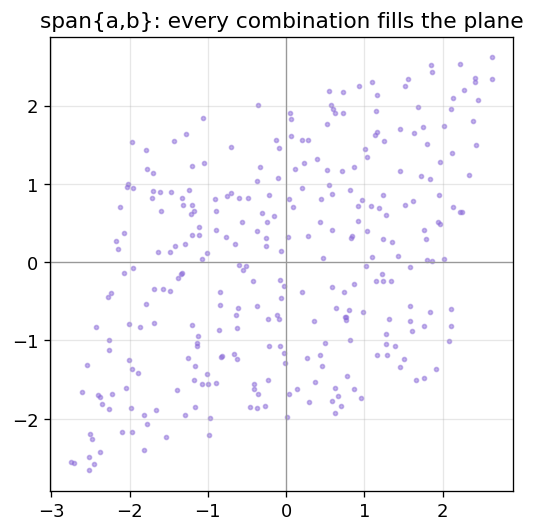

In [25]:
rng = np.random.default_rng(3)
a = np.array([1.6, 0.4])
b = np.array([0.3, 1.5])

# sample many random linear combinations c1*a + c2*b
coeffs = rng.uniform(-1.5, 1.5, size=(300,2))
points = coeffs @ np.array([a,b])

fig, ax = plt.subplots(figsize=(4.6,4.6))
ax.scatter(points[:,0], points[:,1], s=6, alpha=0.5, color=COLORS['e'])
ax.axhline(0,color='#999',lw=0.8); ax.axvline(0,color='#999',lw=0.8)
ax.set_aspect('equal'); ax.set_title("span{a,b}: every combination fills the plane")
plt.tight_layout(); plt.show()

print("closure check: is (2*a + 3*b) still expressible as c1*a+c2*b? trivially yes -- that's closure.")

## 25. Change of Basis

**Math.** If $P$'s columns are a new basis, a vector's coordinates in that
basis are $[v]_B = P^{-1}v$.

**Why?** $P$ is built so that $P \cdot [v]_B$ converts *new* coordinates into
*standard* coordinates (each column of $P$ tells you what one new basis vector
looks like in standard coordinates, and matrix-vector multiplication combines
them). To go the other direction — standard into new — you undo that
conversion with $P^{-1}$.

In [26]:
v = np.array([3.0, 1.4])   # standard coordinates
theta = np.radians(32)
f1 = np.array([np.cos(theta), np.sin(theta)])
f2 = np.array([-np.sin(theta), np.cos(theta)])
P = np.column_stack([f1, f2])

coords_new = np.linalg.inv(P) @ v
print("v in standard coords:", v)
print("new basis vectors: f1 =", f1, " f2 =", f2)
print("v in new-basis coords [v]_B =", coords_new)

# verify: P @ [v]_B reconstructs v
reconstructed = P @ coords_new
print("\nP @ [v]_B == v ?", np.allclose(reconstructed, v))

v in standard coords: [3.  1.4]
new basis vectors: f1 = [0.848 0.53 ]  f2 = [-0.53   0.848]
v in new-basis coords [v]_B = [ 3.286 -0.402]

P @ [v]_B == v ? True


## 26. Projection

**Math.** $\displaystyle p = \frac{a\cdot b}{a\cdot a}\,a$

**Why this formula?** We want the point on the line through $a$ closest to $b$.
Write a candidate point as $p=ta$; the error vector $b-p$ is minimized (closest
point) exactly when it's perpendicular to $a$, i.e. $(b-ta)\cdot a = 0$. Solving
this single equation for $t$ gives $t = \frac{a\cdot b}{a\cdot a}$ — that's the
whole derivation.

t = a.b / a.a = 0.5302013422818792
p = t*a = [1.803 0.318]

residual (b - p) . a = -1.394857383958586e-16  <- ~0, confirms perpendicularity


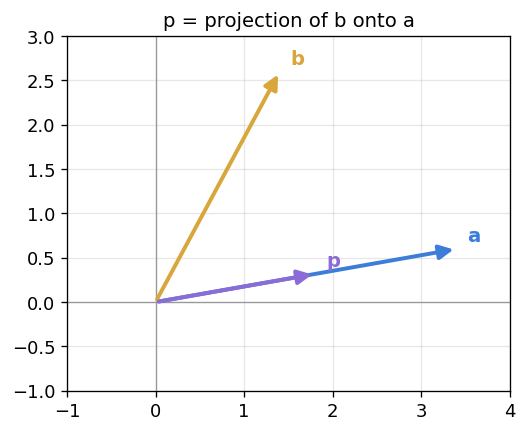

In [27]:
a = np.array([3.4, 0.6])
b = np.array([1.4, 2.6])
t = np.dot(a,b) / np.dot(a,a)
p = t * a
residual = b - p

print("t = a.b / a.a =", t)
print("p = t*a =", p)
print("\nresidual (b - p) . a =", np.dot(residual, a), " <- ~0, confirms perpendicularity")

plot_vectors([a,b,p], colors=[COLORS['a'],COLORS['b'],COLORS['e']],
             labels=['a','b','p'], xlim=(-1,4), ylim=(-1,3),
             title="p = projection of b onto a")

## 27. Least Squares

**Math.** When $Ax=b$ has no exact solution, minimize $\|Ax-b\|^2$. Setting the
gradient to zero gives the **normal equations**:
$$A^TA\,x = A^Tb$$

**Why do we get exactly this equation?** Differentiate
$\|Ax-b\|^2=(Ax-b)^T(Ax-b)$ with respect to $x$ and set it to zero — the
calculus works out to $2A^T(Ax-b)=0$, i.e. $A^TAx=A^Tb$. Geometrically this says
the residual $Ax-b$ must be orthogonal to every column of $A$ (the column
space) — otherwise you could nudge $x$ to shrink the error further.

slope, intercept (normal equations) = [0.513 0.131]
slope, intercept (np.linalg.lstsq)  = [0.513 0.131]


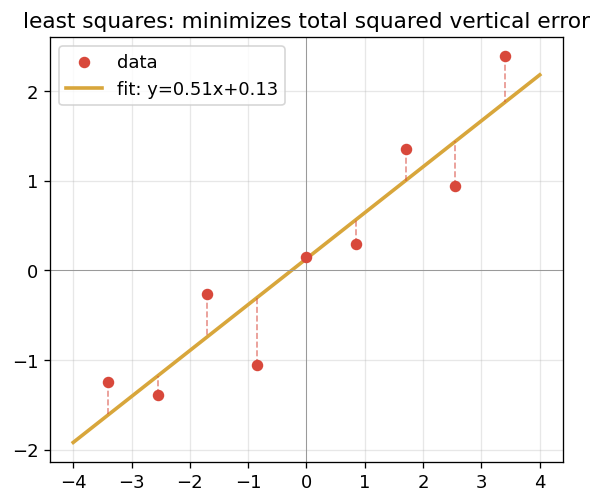

In [28]:
rng = np.random.default_rng(4)
x_data = np.linspace(-3.4, 3.4, 9)
y_data = 0.55*x_data + rng.uniform(-0.7,0.7,size=9)

A = np.column_stack([x_data, np.ones_like(x_data)])   # columns: [x, 1] for y = m*x + c
b = y_data

# solve normal equations directly
coef_normal_eq = np.linalg.inv(A.T @ A) @ A.T @ b
# numpy's stable solver
coef_lstsq, *_ = np.linalg.lstsq(A, b, rcond=None)

print("slope, intercept (normal equations) =", coef_normal_eq)
print("slope, intercept (np.linalg.lstsq)  =", coef_lstsq)

m, c0 = coef_lstsq
fig, ax = plt.subplots(figsize=(5,4.4))
ax.scatter(x_data, y_data, color=COLORS['c'], zorder=3, label='data')
xs = np.linspace(-4,4,50)
ax.plot(xs, m*xs+c0, color=COLORS['b'], lw=2.2, label=f'fit: y={m:.2f}x+{c0:.2f}')
for xi, yi in zip(x_data, y_data):
    ax.plot([xi,xi],[yi, m*xi+c0], color=COLORS['c'], lw=1, ls='--', alpha=0.6)
ax.axhline(0,color='#999',lw=0.6); ax.axvline(0,color='#999',lw=0.6)
ax.legend(); ax.set_title("least squares: minimizes total squared vertical error")
plt.tight_layout(); plt.show()

## 28. Singular Value Decomposition (SVD)

**Math.** Every matrix (even non-square!) factors as $M = U\Sigma V^T$, with
$U,V$ orthogonal and $\Sigma$ diagonal, non-negative.

**Why does this always work, even without eigenvectors?** $M$ itself might not
be square or diagonalizable, but $M^TM$ is *always* square and symmetric — so by
the spectral theorem it always has orthogonal eigenvectors ($V$) and
non-negative eigenvalues ($\sigma_i^2 \ge 0$, since
$v^T(M^TM)v=\|Mv\|^2\ge0$). Those become $\Sigma$'s singular values, and
$U = MV\Sigma^{-1}$ recovers the other orthogonal factor.

In [29]:
M = np.array([[3.0,1.0],[1.0,2.0],[0.5,1.5]])   # non-square, 3x2
U, S, Vt = np.linalg.svd(M)
print("M shape:", M.shape)
print("U shape:", U.shape, " (orthogonal)")
print("singular values:", S)
print("V^T shape:", Vt.shape, " (orthogonal)")

Sigma = np.zeros_like(M, dtype=float)
np.fill_diagonal(Sigma, S)
reconstructed = U @ Sigma @ Vt
print("\nU @ Sigma @ V.T == M ?", np.allclose(reconstructed, M))

# low-rank approximation: keep only the top singular value
S_trunc = S.copy(); S_trunc[1:] = 0
Sigma_trunc = np.zeros_like(M, dtype=float); np.fill_diagonal(Sigma_trunc, S_trunc)
M_rank1 = U @ Sigma_trunc @ Vt
print("\nbest rank-1 approximation of M:\n", M_rank1)
print("approximation error (Frobenius norm):", np.linalg.norm(M - M_rank1))

M shape: (3, 2)
U shape: (3, 3)  (orthogonal)
singular values: [3.833 1.676]
V^T shape: (2, 2)  (orthogonal)

U @ Sigma @ V.T == M ? True

best rank-1 approximation of M:
 [[2.362 1.825]
 [1.594 1.231]
 [1.039 0.803]]
approximation error (Frobenius norm): 1.6755798512746694


## 29. Covariance Matrix

**Math.** For centered data points $x_i$:
$$\Sigma = \frac{1}{n}\sum_i x_i x_i^T$$
Diagonal = variance per dimension; off-diagonal = covariance (co-movement).

**Why the outer-product-average definition?** Each outer product $x_ix_i^T$
produces a matrix of all pairwise products of $x_i$'s coordinates with
themselves. Averaging over every data point gives the *expected* pairwise
product — which is exactly the statistical definition of covariance,
$\text{Cov}(X_j,X_k)=E[X_jX_k]$ (after centering so the mean is zero).

covariance matrix (numpy) =
 [[5.405 2.088]
 [2.088 1.338]]

covariance matrix (manual, x_i x_i^T averaged) =
 [[5.405 2.088]
 [2.088 1.338]]

match? True


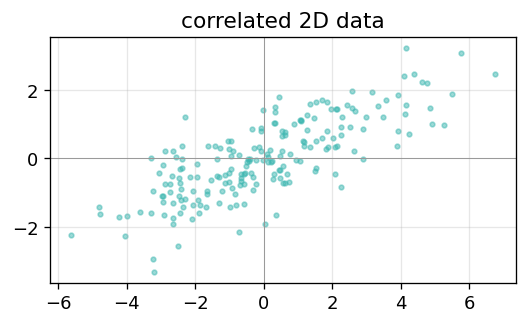

In [30]:
rng = np.random.default_rng(5)
angle = np.radians(22)
u = rng.normal(0, 2.6, 200)
w = rng.normal(0, 0.7, 200)
x = u*np.cos(angle) - w*np.sin(angle)
y = u*np.sin(angle) + w*np.cos(angle)
data = np.column_stack([x,y])
data -= data.mean(axis=0)   # center

cov_numpy = np.cov(data, rowvar=False)
cov_manual = (data.T @ data) / (len(data)-1)
print("covariance matrix (numpy) =\n", cov_numpy)
print("\ncovariance matrix (manual, x_i x_i^T averaged) =\n", cov_manual)
print("\nmatch?", np.allclose(cov_numpy, cov_manual))

fig, ax = plt.subplots(figsize=(4.6,4.6))
ax.scatter(data[:,0], data[:,1], s=8, alpha=0.5, color=COLORS['f'])
ax.set_aspect('equal'); ax.axhline(0,color='#999',lw=0.6); ax.axvline(0,color='#999',lw=0.6)
ax.set_title("correlated 2D data")
plt.tight_layout(); plt.show()

## 30. Principal Component Analysis (PCA)

**Math.** Find $w$ (with $\|w\|=1$) maximizing $\text{Var}(w^Tx)$. Using a
Lagrange multiplier for the constraint gives exactly:
$$\Sigma w = \lambda w$$
— so the best direction is the **top eigenvector of the covariance matrix**,
and the variance captured equals its eigenvalue.

**Why does the optimization reduce to an eigenvalue problem?** $\text{Var}(w^Tx) = w^T\Sigma w$.
Maximizing $w^T\Sigma w$ subject to $w^Tw=1$ is a textbook constrained
optimization: set $\nabla(w^T\Sigma w - \lambda(w^Tw-1)) = 0$, which simplifies
to $2\Sigma w - 2\lambda w = 0$, i.e. $\Sigma w = \lambda w$. So calculus
*forces* the answer to be an eigenvector.

covariance eigenvalues (variance explained): [6.286 0.457]
PC1 direction (top eigenvector): [-0.921 -0.389]
fraction of variance explained by PC1: 0.9322296688633418

sklearn PCA components:
 [[ 0.921  0.389]
 [-0.389  0.921]]
sklearn explained variance: [6.286 0.457]
(signs may differ -- direction is only defined up to a flip)


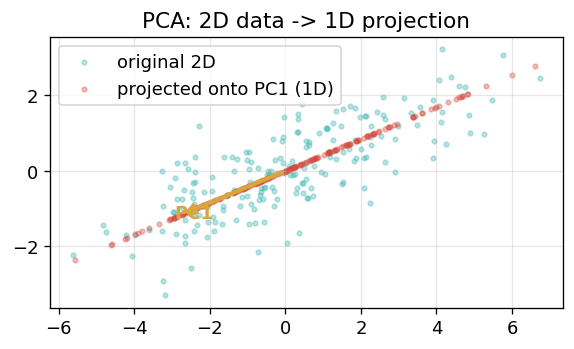

In [31]:
from sklearn.decomposition import PCA

# reuse the correlated data from the covariance section
cov = cov_numpy
eigvals, eigvecs = np.linalg.eigh(cov)
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:,order]
pc1 = eigvecs[:,0]

print("covariance eigenvalues (variance explained):", eigvals)
print("PC1 direction (top eigenvector):", pc1)
print("fraction of variance explained by PC1:", eigvals[0]/eigvals.sum())

# cross-check against scikit-learn's PCA
sk = PCA(n_components=2).fit(data)
print("\nsklearn PCA components:\n", sk.components_)
print("sklearn explained variance:", sk.explained_variance_)
print("(signs may differ -- direction is only defined up to a flip)")

# project onto PC1 -> 1D
projected_1d = data @ pc1
fig, ax = plt.subplots(figsize=(5,4.4))
ax.scatter(data[:,0], data[:,1], s=8, alpha=0.35, color=COLORS['f'], label='original 2D')
ax.annotate('', xy=pc1*3, xytext=(0,0), arrowprops=dict(arrowstyle='-|>', color=COLORS['b'], lw=2.6))
ax.text(*(pc1*3.2), 'PC1', color=COLORS['b'], fontweight='bold')
recon = np.outer(projected_1d, pc1)
ax.scatter(recon[:,0], recon[:,1], s=8, alpha=0.35, color=COLORS['c'], label='projected onto PC1 (1D)')
ax.set_aspect('equal'); ax.legend(); ax.set_title("PCA: 2D data -> 1D projection")
plt.tight_layout(); plt.show()

## Closing: Where to Go Next

You've now derived, computed, and visualized every core object and operation
in linear algebra — not just *what* the formulas are, but *why* they're forced
to look the way they do.

**Natural next steps:**
- Implement **linear regression from scratch** using only what's in this notebook (§27)
- Run **PCA on a real, high-dimensional dataset** (e.g. `sklearn.datasets.load_digits()`) and visualize in 2D
- Derive **backpropagation** as chained matrix derivatives — the calculus rides directly on top of §8 (matrix multiplication) and §6 (transpose)
- Explore **numerical stability**: why `np.linalg.solve` is preferred over explicitly computing `A^-1 @ b`

In [32]:
topics = ["Scalars","Vectors","Matrices","Transpose","Tensors","MatMul","Identity","Inverse",
          "LinSystems","Rank","Null/Col space","Determinant","Trace","Eigen","Diagonalize",
          "Symmetric","Orthogonality","OrthMatrices","Gram-Schmidt","Basis","Independence",
          "VecSpaces","ChangeBasis","Projection","LeastSquares","SVD","Covariance","PCA"]
print(f"Notebook complete: {len(topics)} core topics, each with a derivation + runnable example.")
print("\n -> ".join(topics))

Notebook complete: 28 core topics, each with a derivation + runnable example.
Scalars
 -> Vectors
 -> Matrices
 -> Transpose
 -> Tensors
 -> MatMul
 -> Identity
 -> Inverse
 -> LinSystems
 -> Rank
 -> Null/Col space
 -> Determinant
 -> Trace
 -> Eigen
 -> Diagonalize
 -> Symmetric
 -> Orthogonality
 -> OrthMatrices
 -> Gram-Schmidt
 -> Basis
 -> Independence
 -> VecSpaces
 -> ChangeBasis
 -> Projection
 -> LeastSquares
 -> SVD
 -> Covariance
 -> PCA
